# 路径处理 + 读取 marketing_AB 原始数据

In [17]:
import sys
import pandas as pd
from pathlib import Path

PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.append(str(PROJECT_ROOT))

from src.data_processing import load_marketing_data

df = load_marketing_data(PROJECT_ROOT / "data" / "raw" / "marketing_AB.csv")

df.head()
import matplotlib.pyplot as plt
from pathlib import Path

FIG_DIR = PROJECT_ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# 检查实验组样本占比

In [3]:
group_size = df["test_group"].value_counts().reset_index()
group_size.columns = ["test_group", "users"]

group_size["share"] = group_size["users"] / group_size["users"].sum()
group_size["share_pct"] = group_size["share"].map(lambda x: f"{x:.2%}")

group_size

,test_group,users,share,share_pct
0,ad,564577,0.96,96.00%
1,psa,23524,0.04,4.00%


# 可视化两组样本占比

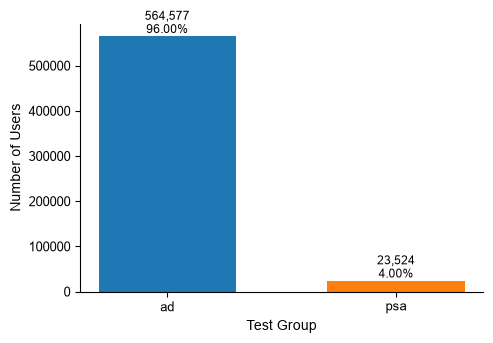

In [ ]:
group_size = df["test_group"].value_counts().reset_index()
group_size.columns = ["test_group", "users"]
group_size["share"] = group_size["users"] / group_size["users"].sum()
group_size["share_pct"] = group_size["share"] * 100

import matplotlib.pyplot as plt
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "DejaVu Sans"],
    "font.size": 9,
    "axes.titlesize":11,
    "axes.labelsize":10,
    "xtick.labelsize":9,
    "ytick.labelsize":9,
    "axes.spines.top":False,
    "axes.spines.right":False
})

plt.figure(figsize=(5, 3.5))

bar_colors = ["#1f77b4", "#ff7f0e"]
bars = plt.bar(group_size["test_group"], group_size["users"], color=bar_colors, width=0.6)

plt.xlabel("Test Group")
plt.ylabel("Number of Users")
for i, row in group_size.iterrows():
    plt.text(
        i,
        row["users"],
        f'{row["users"]:,}\n{row["share_pct"]:.2f}%',
        ha="center",
        va="bottom",
        fontsize=8.5
    )

plt.tight_layout()
plt.savefig(FIG_DIR / "sample_size_by_group.png", dpi=300, bbox_inches="tight")
plt.show()


# 检查两组转化人数是否足够

In [4]:
conversion_count = df.groupby("test_group").agg(
    users=("user_id", "count"),
    conversions=("converted", "sum"),
    non_conversions=("converted", lambda x: (~x).sum()),
    conversion_rate=("converted", "mean")
).reset_index()

conversion_count["conversion_rate_pct"] = conversion_count["conversion_rate"].map(lambda x: f"{x:.2%}")

conversion_count

,test_group,users,conversions,non_conversions,conversion_rate,conversion_rate_pct
0,ad,564577,14423,550154,0.025547,2.55%
1,psa,23524,420,23104,0.017854,1.79%


# 可视化两组转化率

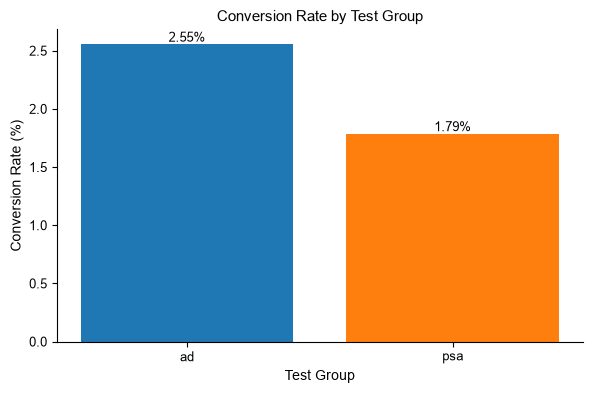

In [15]:
conversion_summary = df.groupby("test_group").agg(
    users=("user_id", "count"),
    conversions=("converted", "sum"),
    conversion_rate=("converted", "mean")
).reset_index()
conversion_summary["conversion_rate_pct"] = conversion_summary["conversion_rate"] * 100

plt.figure(figsize=(6, 4))

bar_colors = ["#1f77b4", "#ff7f0e"]
plt.bar(conversion_summary["test_group"], conversion_summary["conversion_rate_pct"], color=bar_colors)

plt.title("Conversion Rate by Test Group")
plt.xlabel("Test Group")
plt.ylabel("Conversion Rate (%)")
for i, row in conversion_summary.iterrows():
    plt.text(
        i,
        row["conversion_rate_pct"],
        f'{row["conversion_rate_pct"]:.2f}%',
        ha="center",
        va="bottom"
    )
plt.tight_layout()
plt.savefig(FIG_DIR / "conversion_rate_by_group.png", dpi=300, bbox_inches="tight")
plt.show()


# 检查两组曝光次数是否差异很大

In [5]:
ads_exposure_summary = df.groupby("test_group")["total_ads"].agg(
    users="count",
    mean_ads="mean",
    median_ads="median",
    min_ads="min",
    max_ads="max"
).reset_index()

ads_exposure_summary

,test_group,users,mean_ads,median_ads,min_ads,max_ads
0,ad,564577,24.823365,13.0,1,2065
1,psa,23524,24.761138,12.0,1,907


In [6]:
ads_exposure_quantile = df.groupby("test_group")["total_ads"].quantile([0.25, 0.5, 0.75, 0.9, 0.95, 0.99]).reset_index()

ads_exposure_quantile.columns = ["test_group", "quantile", "total_ads"]

ads_exposure_quantile

,test_group,quantile,total_ads
0,ad,0.25,4.00
1,ad,0.50,13.00
2,ad,0.75,27.00
3,ad,0.90,56.00
4,ad,0.95,87.00
5,ad,0.99,201.00
6,psa,0.25,4.00
7,psa,0.50,12.00
8,psa,0.75,26.00
9,psa,0.90,59.00


# 可视化 total_ads 曝光次数分布

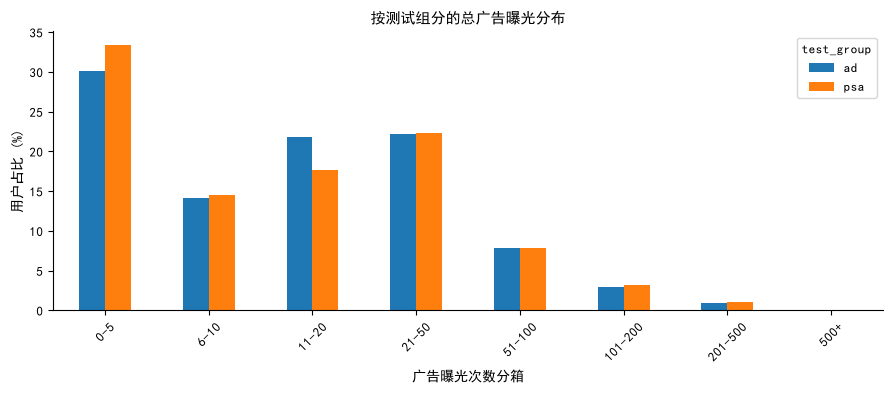

,test_group,ads_bin,users,share,share_pct
0,ad,0-5,169962,0.301043,30.104308
1,ad,6-10,79537,0.140879,14.087892
2,ad,11-20,123334,0.218454,21.845382
3,ad,21-50,125541,0.222363,22.236294
4,ad,51-100,44149,0.078198,7.819837
5,ad,101-200,16360,0.028977,2.897745
6,ad,201-500,5128,0.009083,0.908291
7,ad,500+,566,0.001003,0.100252
8,psa,0-5,7861,0.334169,33.416936
9,psa,6-10,3415,0.145171,14.517089


In [23]:
import matplotlib.pyplot as plt
import pandas as pd

# 解决中文乱码警告
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

bins = [0, 5, 10, 20, 50, 100, 200, 500, df["total_ads"].max()]
labels = ["0-5", "6-10", "11-20", "21-50", "51-100", "101-200", "201-500", "500+"]
df["ads_bin"] = pd.cut(
    df["total_ads"],
    bins=bins,
    labels=labels,
    include_lowest=True
)
ads_dist = df.groupby(["test_group", "ads_bin"], observed=True).size().reset_index(name="users")
ads_dist["share"] = ads_dist["users"] / ads_dist.groupby("test_group")["users"].transform("sum")
ads_dist["share_pct"] = ads_dist["share"] * 100
ads_pivot = ads_dist.pivot(
    index="ads_bin",
    columns="test_group",
    values="share_pct"
).fillna(0)

ads_pivot.plot(kind="bar", figsize=(9, 4))
plt.title("按测试组分的总广告曝光分布")
plt.xlabel("广告曝光次数分箱")
plt.ylabel("用户占比 (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(FIG_DIR / "total_ads_distribution_by_group.png", dpi=300)
plt.show()
ads_dist


# 看不同曝光次数下的转化率

In [19]:
import numpy as np

bins = [0, 5, 10, 20, 50, 100, 200, 500, np.inf]
labels = ["0-5", "6-10", "11-20", "21-50", "51-100", "101-200", "201-500", "500+"]

df["ads_bin"] = pd.cut(
    df["total_ads"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

exposure_conversion = df.groupby(
    ["test_group", "ads_bin"],
    observed=True
).agg(
    users=("user_id", "count"),
    conversions=("converted", "sum"),
    conversion_rate=("converted", "mean")
).reset_index()

exposure_conversion["conversion_rate_pct"] = exposure_conversion["conversion_rate"] * 100

exposure_conversion

,test_group,ads_bin,users,conversions,conversion_rate,conversion_rate_pct
0,ad,0-5,169962,427,0.002512,0.251233
1,ad,6-10,79537,386,0.004853,0.485309
2,ad,11-20,123334,1036,0.008400,0.839995
3,ad,21-50,125541,3660,0.029154,2.915382
4,ad,51-100,44149,5135,0.116311,11.631068
5,ad,101-200,16360,2892,0.176773,17.677262
6,ad,201-500,5128,788,0.153666,15.366615
7,ad,500+,566,99,0.174912,17.491166
8,psa,0-5,7861,22,0.002799,0.279863
9,psa,6-10,3415,23,0.006735,0.673499


# 曝光次数分箱转化率

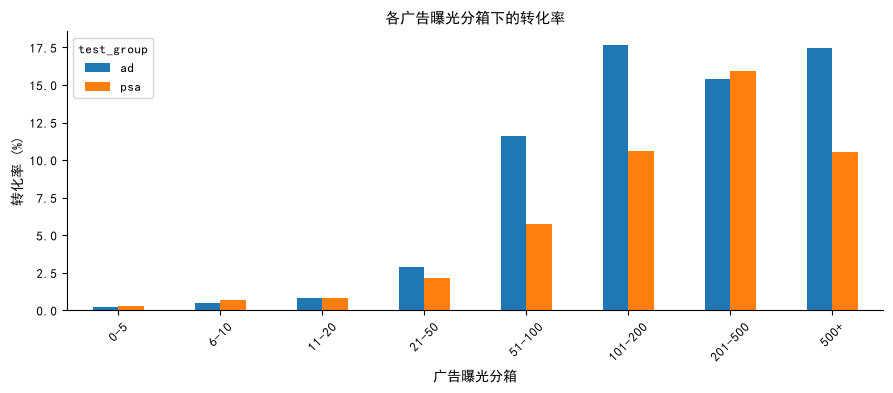

In [24]:
exposure_conversion_pivot = exposure_conversion.pivot(
    index="ads_bin",
    columns="test_group",
    values="conversion_rate_pct"
).fillna(0)
exposure_conversion_pivot.plot(kind="bar", figsize=(9, 4))
plt.title("各广告曝光分箱下的转化率")
plt.xlabel("广告曝光分箱")
plt.ylabel("转化率 (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(FIG_DIR / "conversion_rate_by_total_ads_bin.png", dpi=300)
plt.show()


total_ads必须分析，不能只做 ad/psa 总体转化率。

# 保存实验检查结果

In [7]:
group_size.to_csv("../data/processed/group_size_summary.csv", index=False)
conversion_count.to_csv("../data/processed/conversion_count_summary.csv", index=False)
ads_exposure_summary.to_csv("../data/processed/ads_exposure_summary.csv", index=False)
ads_exposure_quantile.to_csv("../data/processed/ads_exposure_quantile.csv", index=False)